# Project 2: Exploratory Data Analysis (EDA)

## Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on the cleaned dataset to understand data distributions, identify patterns and trends, detect outliers, and generate meaningful business insights.

### Tasks Performed

- Dataset Overview
- Descriptive Statistics
- Distribution Analysis
- Trend Analysis
- Outlier Detection
- Category-wise Analysis
- Business Insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Loding The Dataset 

In [3]:
df = pd.read_excel("Cleaned_Data_Analytics_Project.xlsx")

In [5]:
df.sample(5)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,CalculatedTotal
392,ORD200392,2024-02-28,C95100,Phone,1,627.20,197 Main St,Online,Delivered,TRK47366265,1,WINTER15,Email,627.20,627.20
816,ORD200816,2024-02-21,C55286,Tablet,5,574.79,497 Main St,Credit Card,Pending,TRK39058734,8,WINTER15,Referral,2873.95,2873.95
405,ORD200405,2025-01-26,C97774,Monitor,4,451.97,603 Main St,Online,Cancelled,TRK64664424,7,WINTER15,Email,1807.88,1807.88
592,ORD200592,2024-04-23,C42306,Phone,3,204.27,938 Main St,Online,Returned,TRK15499648,4,No Coupon,Google,612.81,612.81
122,ORD200122,2024-04-15,C96787,Laptop,2,533.02,588 Main St,Gift Card,Shipped,TRK30422853,2,No Coupon,Facebook,1066.04,1066.04


# Step 1: Dataset Overview

This section provides a general understanding of the dataset structure including dimensions, variables, and data types.

In [7]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1200
Columns : 15


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
 14  CalculatedTotal  1200 non-null   float64

# Step 2: Descriptive Statistics

Descriptive statistics summarize the central tendency and spread of numerical variables.

In [9]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice,CalculatedTotal
count,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558,819.856558


In [10]:
numeric_cols = ['Quantity','UnitPrice','ItemsInCart','TotalPrice']

for col in numeric_cols:
    print(f"\n{col}")
    print("Count :", df[col].count())
    print("Mean :", round(df[col].mean(),2))
    print("Median :", round(df[col].median(),2))


Quantity
Count : 1200
Mean : 2.95
Median : 3.0

UnitPrice
Count : 1200
Mean : 356.41
Median : 364.21

ItemsInCart
Count : 1200
Mean : 5.48
Median : 5.0

TotalPrice
Count : 1200
Mean : 1053.97
Median : 823.62


# Step 3: Distribution of Total Order Value

Understanding the distribution of TotalPrice helps identify customer spending behavior.

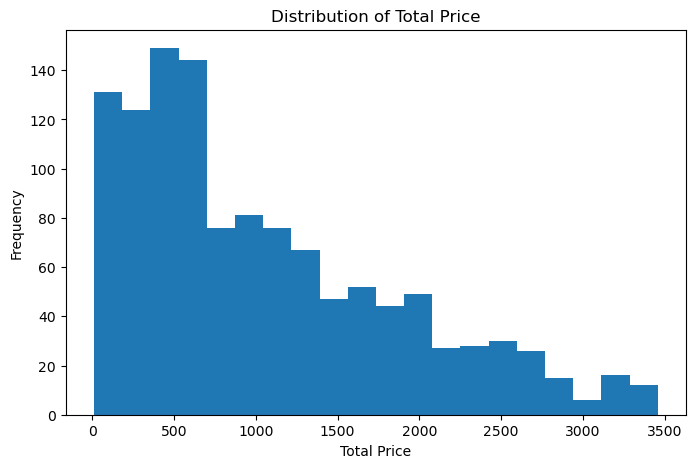

In [11]:
plt.figure(figsize=(8,5))
plt.hist(df['TotalPrice'], bins=20)
plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.show()

# Step 4: Product Analysis

This section identifies the most frequently purchased products.

In [12]:
top_products = df['Product'].value_counts()

top_products

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

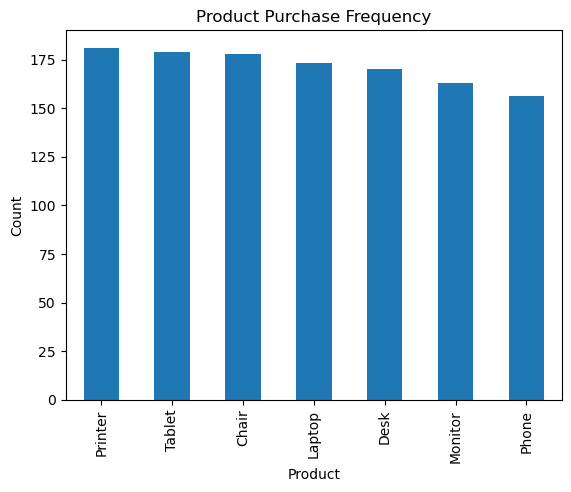

In [18]:
ax = top_products.plot(kind='bar')

plt.title("Product Purchase Frequency")
plt.xlabel("Product")
plt.ylabel("Count")
plt.show()

# Simple labels on bars
for i in ax.containers:
    ax.bar_label(i)

plt.show()

# Step 5: Payment Method Analysis

This analysis examines customer payment preferences.

In [19]:
payment_counts = df['PaymentMethod'].value_counts()

payment_counts

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

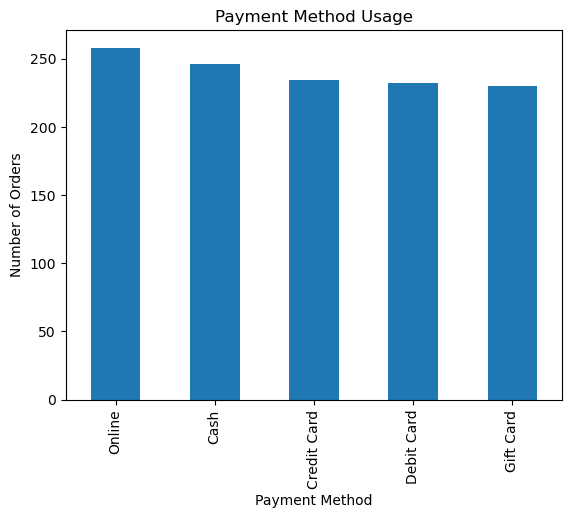

In [20]:
payment_counts.plot(kind='bar')

plt.title("Payment Method Usage")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.show()

# Step 6: Order Status Analysis

This section evaluates the distribution of order statuses.

In [21]:
status_counts = df['OrderStatus'].value_counts()

status_counts

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

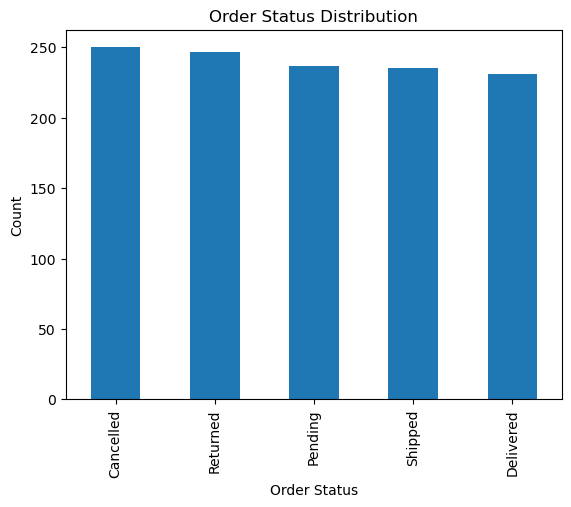

In [22]:
status_counts.plot(kind='bar')

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.show()

# Step 7: Referral Source Analysis

This analysis identifies the most effective customer acquisition channels.|

In [23]:
referral_counts = df['ReferralSource'].value_counts()

referral_counts

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

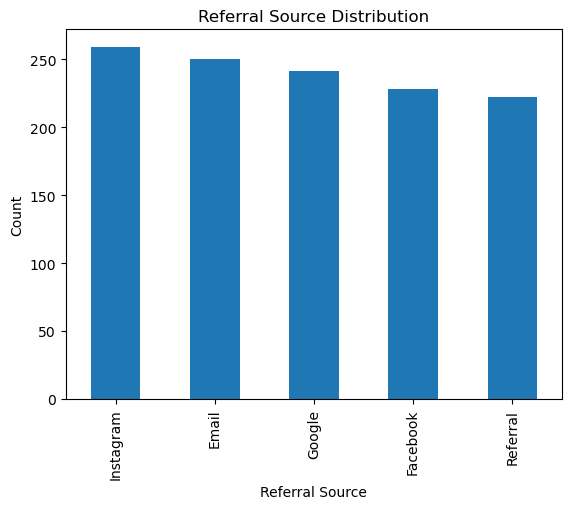

In [24]:
referral_counts.plot(kind='bar')

plt.title("Referral Source Distribution")
plt.xlabel("Referral Source")
plt.ylabel("Count")
plt.show()

# Step 8: Monthly Order Trend

Trend analysis helps identify changes in customer activity over time.

In [25]:
df['Month'] = df['Date'].dt.month

In [26]:
monthly_orders = df.groupby('Month')['OrderID'].count()

monthly_orders

Month
1     106
2     106
3     128
4     113
5     120
6     147
7      87
8      79
9      73
10     78
11     76
12     87
Name: OrderID, dtype: int64

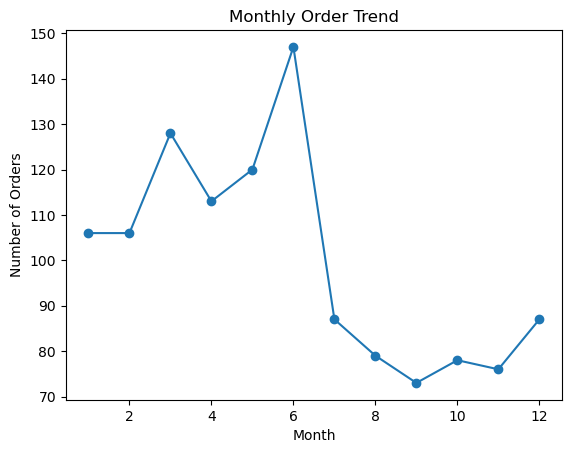

In [27]:
monthly_orders.plot(marker='o')

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()

# Step 9: Outlier Detection

Outliers are unusual observations that differ significantly from the majority of data points.

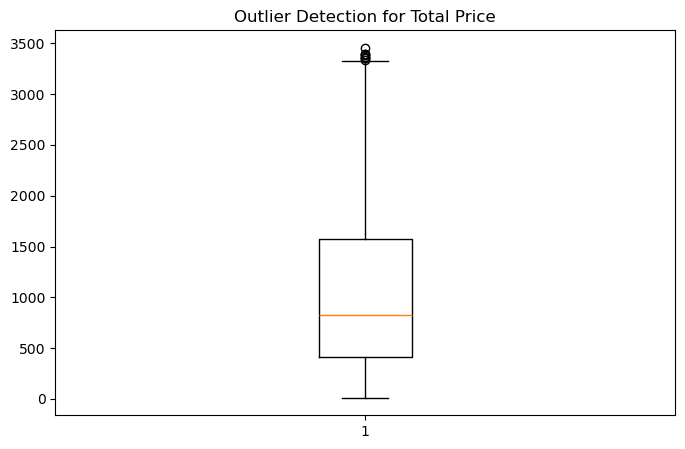

In [28]:
plt.figure(figsize=(8,5))

plt.boxplot(df['TotalPrice'])

plt.title("Outlier Detection for Total Price")

plt.show()

## IQR Method

In [29]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[(df['TotalPrice'] < lower) | (df['TotalPrice'] > upper)]

print("Number of Outliers :", len(outliers))

Number of Outliers : 8


# Step 10: Key Findings and Observations

## Descriptive Statistics

1. The dataset contains 1,200 transaction records covering the period from January 2023 to June 2025.

2. The average order quantity was 2.95 units, while the median quantity was 3 units, indicating that most customers purchased approximately three items per transaction.

3. The average unit price was ₹356.41 and the median unit price was ₹364.21, suggesting a fairly balanced distribution of product prices.

4. The average total transaction value was ₹1,053.97, whereas the median transaction value was ₹823.62. Since the mean is higher than the median, a small number of high-value transactions increased the overall average order value.

5. Customers added an average of 5.48 items to their cart, with a median of 5 items, indicating consistent shopping behavior across transactions.

---

## Product Analysis

1. Printer was the most frequently purchased product with 181 orders.

2. Tablet (179 orders) and Chair (178 orders) were also among the most popular products.

3. Product demand was relatively balanced across all product categories, as the difference between the highest and lowest purchased products was small.

4. No single product category dominated sales, suggesting diversified customer purchasing preferences.

---

## Payment Method Analysis

1. Online payment was the most commonly used payment method with 258 transactions.

2. Cash (246 transactions), Credit Card (234 transactions), Debit Card (232 transactions), and Gift Card (230 transactions) showed similar usage patterns.

3. The relatively even distribution indicates that customers prefer multiple payment options rather than relying on a single payment method.

---

## Order Status Analysis

1. Cancelled orders accounted for the highest number of transactions (250).

2. Returned orders were also relatively high at 247 transactions.

3. Delivered, Shipped, and Pending orders were distributed fairly evenly.

4. The high number of cancelled and returned orders may indicate operational, product satisfaction, or order management challenges that require further investigation.

---

## Referral Source Analysis

1. Instagram generated the highest number of customer referrals with 259 transactions.

2. Email marketing contributed 250 transactions and Google contributed 241 transactions.

3. Facebook and customer referrals also generated a substantial number of orders.

4. Social and digital marketing channels appear to be effective sources of customer acquisition.

---

## Monthly Trend Analysis

1. The highest order volume was observed in June with 147 orders.

2. March recorded 128 orders and May recorded 120 orders, indicating strong customer activity during the first half of the year.

3. Order volumes gradually declined after June, with September showing the lowest number of transactions (73 orders).

4. The results suggest possible seasonality in customer purchasing behavior, with stronger sales during the first half of the year.

---

## Distribution Analysis of Total Price

1. The TotalPrice distribution is positively skewed because the mean transaction value (₹1,053.97) is higher than the median value (₹823.62).

2. Most transactions are concentrated in the lower and middle price ranges, while relatively few transactions occur at very high values.

3. The histogram indicates that customer purchases are generally moderate in value, with a small number of expensive transactions extending the upper tail of the distribution.

4. This pattern is common in retail datasets where a limited number of customers make large purchases while the majority place average-sized orders.

---

## Outlier Analysis

1. Outlier detection was performed using the Interquartile Range (IQR) method on the TotalPrice variable.

2. A total of 8 outliers were identified.

3. These outliers represent unusually high-value transactions compared to the majority of orders.

4. Since these transactions may correspond to legitimate large purchases, they should be investigated before removal rather than automatically excluded from the dataset.

5. The small number of outliers (8 out of 1,200 records) indicates that extreme values have limited impact on the overall dataset.